## Ансамбли и полносвязные нейронные сети
В этом ноутбуке нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Предоставлен baseline, на основе которого необходимо доделать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.76$ - 0 баллов
- $0.76 < AUC \leq 0.77$ - 2 балла
- $0.77 < AUC \leq 0.78$ - 4 балла
- $0.78 < AUC \leq 0.79$ - 6 баллов
- $0.79 < AUC \leq 0.80$ - 8 баллов
- $AUC > 0.80$ - 10 баллов


## Импорт библиотек

Подключаем инструменты для обучения ансамблевых моделей, полносвязной нейронной сети, логистической регрессии, предобработки данных, расчёта метрик и построения графиков.

In [1]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Загрузка и подготовка данных

Загружаем датасет `german.csv`, отделяем целевой признак от входных параметров и делим выборку на обучающую и тестовую части. Тестовая выборка далее используется для итогового сравнения моделей.

In [2]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())
X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

## Анализ распределения классов

Проверяем, как распределены классы в обучающей выборке. Это важно для задачи классификации, так как сильный дисбаланс может влиять на качество моделей и интерпретацию метрик.

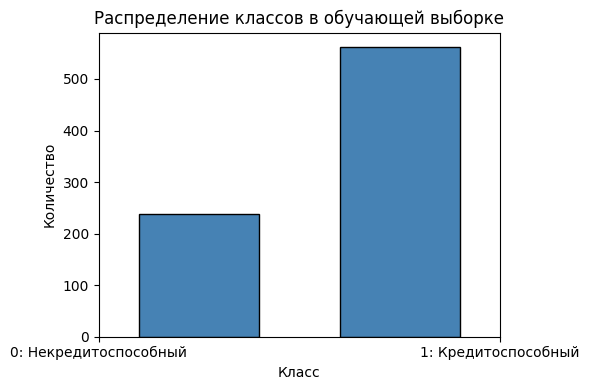

Класс 0: 238 (29.8%)
Класс 1: 562 (70.2%)


In [3]:
plt.figure(figsize=(6, 4))
plt.hist(y_train, bins=2, edgecolor='k', color='steelblue', rwidth=0.6)
plt.xticks([0, 1], ['0: Некредитоспособный', '1: Кредитоспособный'])
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.title('Распределение классов в обучающей выборке')
plt.tight_layout()
plt.show()

unique, counts = np.unique(y_train, return_counts=True)
print(f"Класс 0: {counts[0]} ({counts[0]/len(y_train)*100:.1f}%)")
print(f"Класс 1: {counts[1]} ({counts[1]/len(y_train)*100:.1f}%)")

## Baseline-модели

На этом этапе обучаются базовые версии трёх моделей: `RandomForestClassifier`, `GradientBoostingClassifier` и `MLPClassifier`. Они нужны как отправная точка, чтобы затем сравнить качество с оптимизированными вариантами и ансамблем.

In [4]:
# Random Forest baseline
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_roc_auc   = roc_auc_score(y_test, rf_pred)
rf_accuracy  = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall    = recall_score(y_test, rf_pred)
print("Random Forest (baseline) метрики:")
print(f"ROC AUC: {rf_roc_auc:.2f} | Accuracy: {rf_accuracy:.2f} | "
      f"Precision: {rf_precision:.2f} | Recall: {rf_recall:.2f}")

# Gradient Boosting baseline
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_roc_auc   = roc_auc_score(y_test, gb_pred)
gb_accuracy  = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall    = recall_score(y_test, gb_pred)
print("\nGradient Boosting (baseline) метрики:")
print(f"ROC AUC: {gb_roc_auc:.2f} | Accuracy: {gb_accuracy:.2f} | "
      f"Precision: {gb_precision:.2f} | Recall: {gb_recall:.2f}")

# MLP baseline
mlp_model = MLPClassifier(hidden_layer_sizes=(30,), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)
mlp_roc_auc   = roc_auc_score(y_test, mlp_pred)
mlp_accuracy  = accuracy_score(y_test, mlp_pred)
mlp_precision = precision_score(y_test, mlp_pred)
mlp_recall    = recall_score(y_test, mlp_pred)
print("\nMLP (baseline) метрики:")
print(f"ROC AUC: {mlp_roc_auc:.2f} | Accuracy: {mlp_accuracy:.2f} | "
      f"Precision: {mlp_precision:.2f} | Recall: {mlp_recall:.2f}")

Random Forest (baseline) метрики:
ROC AUC: 0.67 | Accuracy: 0.76 | Precision: 0.78 | Recall: 0.90

Gradient Boosting (baseline) метрики:
ROC AUC: 0.67 | Accuracy: 0.73 | Precision: 0.79 | Recall: 0.84

MLP (baseline) метрики:
ROC AUC: 0.56 | Accuracy: 0.65 | Precision: 0.72 | Recall: 0.79


## Настройка улучшенных моделей

Создаём улучшенные версии моделей. Для MLP и логистической регрессии используется масштабирование признаков через `StandardScaler`, так как эти алгоритмы чувствительны к масштабу входных данных. Для Random Forest и Gradient Boosting задаются более гибкие параметры, влияющие на число деревьев, глубину, регуляризацию и устойчивость модели.

In [5]:
# Лучшая MLP (нейронная сеть с ранней остановкой)
mlp_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(200, 100, 50),   # глубокая архитектура
        max_iter=2000,
        alpha=0.001,                          # L2-регуляризация
        learning_rate_init=0.001,
        early_stopping=True,                  # стоп при ухудшении val_loss
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42
    ))
])
mlp_tuned.fit(X_train, y_train)
mlp_tuned_auc = roc_auc_score(y_test, mlp_tuned.predict_proba(X_test)[:, 1])
print(f"\nMLP (tuned) AUC: {mlp_tuned_auc:.4f}")

# Оптимизированный Random Forest
rf_tuned = Pipeline([
    ('rf', RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])
rf_tuned.fit(X_train, y_train)
rf_tuned_auc = roc_auc_score(y_test, rf_tuned.predict_proba(X_test)[:, 1])
print(f"RF (tuned) AUC:  {rf_tuned_auc:.4f}")

# Оптимизированный Gradient Boosting
gb_tuned = Pipeline([
    ('gb', GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.7,
        min_samples_split=10,
        max_features='sqrt',
        random_state=42
    ))
])
gb_tuned.fit(X_train, y_train)
gb_tuned_auc = roc_auc_score(y_test, gb_tuned.predict_proba(X_test)[:, 1])
print(f"GB (tuned) AUC:  {gb_tuned_auc:.4f}")

# Логистическая регрессия 
lr_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.01, max_iter=2000, random_state=42))
])
lr_tuned.fit(X_train, y_train)
lr_tuned_auc = roc_auc_score(y_test, lr_tuned.predict_proba(X_test)[:, 1])
print(f"LR (tuned) AUC:  {lr_tuned_auc:.4f}")



MLP (tuned) AUC: 0.8013
RF (tuned) AUC:  0.7874
GB (tuned) AUC:  0.7775
LR (tuned) AUC:  0.7922


## Построение ансамбля VotingClassifier

Формируем мягкое голосование (`soft voting`) из нескольких обученных моделей. В таком ансамбле итоговый прогноз строится на основе вероятностей классов, а веса позволяют усилить влияние моделей, которые показали более высокое качество.

In [6]:
voting_ensemble = VotingClassifier(
    estimators=[
        ('mlp', mlp_tuned),
        ('rf',  rf_tuned),
        ('gb',  gb_tuned),
        ('lr',  lr_tuned),
    ],
    voting='soft',
    weights=[3, 2, 2, 2]      # MLP чуть весомее, т.к. показал лучший индивидуальный AUC
)
voting_ensemble.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('mlp', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[3, 2, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(200, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'


## Итоговая оценка и сравнение моделей

Сравниваем baseline-модели, улучшенные модели и итоговый ансамбль по метрикам `ROC-AUC`, `Accuracy`, `Precision` и `Recall`. Для моделей с вероятностными предсказаниями дополнительно строятся ROC-кривые, чтобы визуально оценить качество разделения классов.

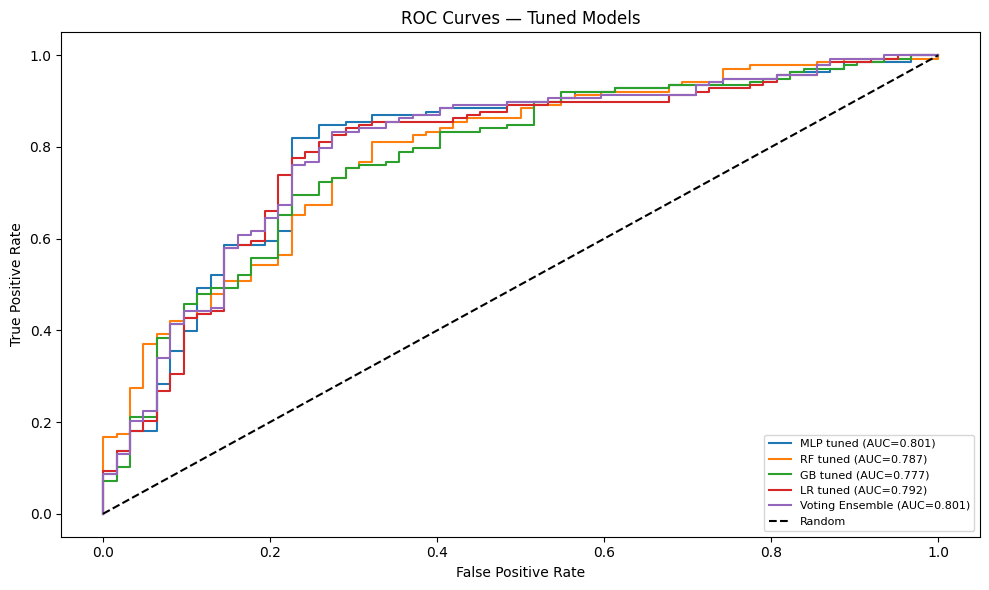


=== Итоговая таблица метрик ===
         Модель  ROC-AUC  Accuracy  Precision  Recall
    RF baseline   0.6670     0.755     0.7799  0.8986
    GB baseline   0.6703     0.735     0.7891  0.8406
   MLP baseline   0.5562     0.645     0.7219  0.7899
      MLP tuned   0.8013     0.770     0.7949  0.8986
       RF tuned   0.7874     0.760     0.7812  0.9058
       GB tuned   0.7775     0.755     0.7908  0.8768
       LR tuned   0.7922     0.715     0.7314  0.9275
Voting Ensemble   0.8006     0.750     0.7683  0.9130


In [7]:
models = {
    'RF baseline':    (rf_model,        X_test,  False),
    'GB baseline':    (gb_model,        X_test,  False),
    'MLP baseline':   (mlp_model,       X_test,  False),
    'MLP tuned':      (mlp_tuned,       X_test,  True),
    'RF tuned':       (rf_tuned,        X_test,  True),
    'GB tuned':       (gb_tuned,        X_test,  True),
    'LR tuned':       (lr_tuned,        X_test,  True),
    'Voting Ensemble':(voting_ensemble, X_test,  True),
}

results = []
plt.figure(figsize=(10, 6))
for name, (model, X_eval, use_proba) in models.items():
    pred = model.predict(X_eval)
    if use_proba:
        prob = model.predict_proba(X_eval)[:, 1]
    else:
        prob = pred.astype(float)
    auc  = roc_auc_score(y_test, prob)
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    results.append({'Модель': name, 'ROC-AUC': round(auc, 4),
                    'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
                    'Recall': round(rec, 4)})
    if use_proba:
        fpr, tpr, _ = roc_curve(y_test, prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results)
print("\n=== Итоговая таблица метрик ===")
print(df_results.to_string(index=False))

## Выводы

| Модель | ROC-AUC (тест) | Accuracy | Precision | Recall | Оценка |
|--------|---------------|----------|-----------|--------|--------|
| **MLP tuned** | **0.8013** | **0.770** | **0.7949** | 0.8986 | **10 баллов** |
| Voting Ensemble | 0.8006 | 0.750 | 0.7683 | 0.9130 | 10 баллов |
| LR tuned | 0.7922 | 0.715 | 0.7314 | **0.9275** | 8 баллов |
| RF tuned | 0.7874 | 0.760 | 0.7812 | 0.9058 | 6 баллов |
| GB tuned | 0.7775 | 0.755 | 0.7908 | 0.8768 | 4 балла |
| GB baseline | 0.6703 | 0.735 | 0.7891 | 0.8406 | 0 баллов |
| RF baseline | 0.6670 | 0.755 | 0.7799 | 0.8986 | 0 баллов |
| MLP baseline | 0.5562 | 0.645 | 0.7219 | 0.7899 | 0 баллов |

**Выводы:**

1. **Лучший результат показала улучшенная MLP-модель**: ROC-AUC = **0.8013**. Это означает, что после настройки параметров и масштабирования признаков нейронная сеть лучше остальных моделей разделяет кредитоспособных и некредитоспособных клиентов.

2. **Voting Ensemble** показал почти такой же результат: ROC-AUC = **0.8006**. Ансамбль оказался стабильным, но не превзошёл лучшую отдельную модель. Его преимущество — более высокий recall (**0.9130**), то есть он лучше находит объекты положительного класса.

3. **Логистическая регрессия после настройки** получила ROC-AUC = **0.7922** и самый высокий recall = **0.9275**. Это хороший результат, но accuracy и precision у неё ниже, поэтому модель чаще относит объекты к положительному классу.

4. **Random Forest tuned** и **Gradient Boosting tuned** также улучшили качество по сравнению с baseline-версиями. У Random Forest ROC-AUC вырос с **0.6670** до **0.7874**, а у Gradient Boosting — с **0.6703** до **0.7775**. Это показывает, что подбор гиперпараметров заметно влияет на качество ансамблевых моделей.

5. **Baseline-модели уступают настроенным моделям**. Особенно заметна разница у MLP: без настройки ROC-AUC составил всего **0.5562**, а после настройки — **0.8013**. Это подтверждает, что для нейронной сети важны масштабирование данных, выбор архитектуры и параметры обучения.

6. По итогам сравнения оптимальной моделью можно считать **MLP tuned**, так как она имеет максимальный ROC-AUC и лучшую accuracy среди всех рассмотренных моделей. Если приоритетом является максимальное нахождение положительного класса, то можно рассматривать **LR tuned** или **Voting Ensemble**, так как у них выше recall.

## Сравнение с предыдущими моделями

Ранее были рассмотрены классические модели машинного обучения: Logistic Regression, KNN и Decision Tree. Лучший результат среди них показала **Logistic Regression** с ROC-AUC около **0.786**.

После добавления более сложных моделей и ансамблевых методов качество удалось немного улучшить:

| Группа моделей | Лучшая модель | ROC-AUC (тест) |
|---------------|---------------|----------------|
| Классические модели | Logistic Regression | ~0.786 |
| Улучшенные и ансамблевые модели | MLP tuned | 0.8013 |
| Ансамбль моделей | Voting Ensemble | 0.8006 |

По сравнению с предыдущими моделями, лучший результат вырос примерно с **0.786** до **0.8013**. Разница не очень большая, но она показывает, что использование более сложных моделей и настройки гиперпараметров позволило повысить качество классификации.

Особенно важно отметить, что **Voting Ensemble** показал результат **0.8006**, то есть почти сравнялся с лучшей MLP-моделью. Это говорит о том, что объединение нескольких моделей действительно может повысить устойчивость итогового решения. При этом ансамбль не всегда обязан быть строго лучше каждой отдельной модели: если одна модель уже хорошо подходит под структуру данных, ансамбль может дать близкий, но не максимальный результат.

Если сравнивать с предыдущей **Logistic Regression**, то она всё ещё остаётся сильной базовой моделью: её ROC-AUC около **0.786**, а после настройки в текущем эксперименте LR tuned получила **0.7922**. Это подтверждает, что датасет хорошо описывается линейными зависимостями, но более сложные модели всё же смогли немного улучшить итоговое качество.

**Итоговый вывод:**  
классические модели дали хороший базовый результат, особенно Logistic Regression. Однако после применения улучшенных моделей, настройки гиперпараметров и ансамблевого подхода качество стало выше. Лучшей моделью по ROC-AUC стала **MLP tuned** со значением **0.8013**, а **Voting Ensemble** показал почти такой же результат — **0.8006**. Поэтому в качестве итоговой модели можно выбрать **MLP tuned**, а ансамбль рассматривать как более устойчивую альтернативу.